# KF M1+M9 EnbPI

Giordano M1 and M9 conditional-mean equations combined additively (retaining the project's coupled volatility and observation noise) → causal Kalman decomposition → moving-block bootstrap of centered base-ARIMA one-step residuals to fit B low-frequency ARIMA models conditioned on the actual causal history + B high-frequency point ANNs trained with MSE to predict H_t → official-style nested OOB mean aggregation and EnbPI calibration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

from kf_forecasting.models import kf_enbpi
importlib.reload(kf_enbpi)

from kf_forecasting.models.kf_enbpi import (
    EnbPIConfig, simulate_and_run, monte_carlo_summary,
    plot_result, plot_monte_carlo_summary, plot_monte_carlo_forecast_diagnostics,
)

pd.set_option('display.precision', 4)
print(f'Loaded kf_enbpi from: {kf_enbpi.__file__}')

Loaded kf_enbpi from: C:\Users\User\Desktop\程式\project\meeting\src\kf_forecasting\models\kf_enbpi.py


## Experiment configuration
`batch_size=1` means the response is revealed after each forecast. For larger batches, forecasts are recursive inside the batch and truths update the residual pool only after the whole batch. The low and high panels use separate online EnbPI residual pools calibrated against the causal KF component references. With `oob_bias_correction_mode='combined'`, low/high are first recombined and the mean final OOB residual then corrects only the final point forecast; interval quantiles use centered final residuals to avoid double correction.

In [14]:
config = EnbPIConfig(
    window_size=15,
    alpha=0.05,
    n_bootstrap=30,
    block_length=None,  # defaults to round(sqrt(number of training windows))
    batch_size=1,
    beta_grid_size=101,
    oob_bias_correction=True,
    oob_bias_correction_mode='combined',
    arima_order=None,  # BIC selection; bootstrap parameters use actual causal history at prediction
    arima_max_p=4,
    arima_max_q=4,
    ann_hidden_layers=(32, 16),
    ann_max_iter=500,
    ann_alpha=1e-4,
    ann_learning_rate_init=1e-3,
    ann_target_standardization=True,
    ann_early_stopping=False,  # 禁用 sklearn 隨機 validation split
    ann_rolling_validation=True,
    ann_rolling_splits=3,
    ann_validation_fraction=0.10,
    ann_iteration_candidates=(125, 250, 500),
    ann_tol=1e-3,
    random_state=1234,
)
train_size = 650
horizon = 200

## One reproducible run

Actual result: train_size=650, forecast_start=650, total_length=850
Data seed=2026, ensemble seed=1234


,model,data_seed,ensemble_seed,arima_order,mse,rmse,coverage_percent,mean_width,mean_beta,mean_bias_correction,bias_correction_mode,ann_selected_max_iter_mean,ann_rolling_validation_mse,ann_nonconverged_models,elapsed_seconds
0,m1m9,2026,1234,"(2, 0, 0)",3.5501,1.8842,97.5,7.9512,0.0166,-0.1401,combined,125.0,3.3999,30,59.2746


,component,reference,mse,rmse,coverage_percent,enbpi_mean_width,mean_beta,mean_bias_correction
0,low_arima,kalman_low,0.1990,0.4460,96.0,1.8624,0.0200,0.0
1,high_ann_mse,kalman_high,2.3045,1.5180,96.5,6.2729,0.0218,0.0
2,low_arima,true_low,5.1607,2.2717,34.0,1.8624,0.0200,0.0
3,high_ann_mse,true_high,7.9672,2.8226,77.5,6.2729,0.0218,0.0


,time,truth,point,lower,upper,low_reference,low_point,low_lower,low_upper,low_covered,...,high_lower,high_upper,high_covered,high_beta,bias_correction,low_bias_correction,high_bias_correction,covered,width,beta
0,650,-3.2309,-3.1446,-7.7510,0.2951,-3.3591,-3.0519,-4.1395,-2.2460,True,...,-3.5325,2.7823,True,0.0215,-0.0049,0.0,0.0,True,8.0461,0.0135
1,651,-0.6386,-2.6481,-7.2519,0.7942,-2.8150,-3.0418,-4.1293,-2.2359,True,...,-3.0435,3.2713,True,0.0215,-0.0075,0.0,0.0,True,8.0461,0.0135
2,652,-1.3044,-2.0652,-6.6689,1.3772,-2.5129,-2.5992,-3.6867,-1.7933,True,...,-2.9031,3.4118,True,0.0215,-0.0076,0.0,0.0,True,8.0461,0.0135
3,653,-0.6474,-1.5626,-6.1682,1.8778,-2.1398,-2.3319,-3.4194,-1.5260,True,...,-2.6698,3.6450,True,0.0215,-0.0056,0.0,0.0,True,8.0461,0.0135
4,654,-3.7916,-0.3431,-4.9518,3.0943,-2.4702,-2.0169,-3.1044,-1.2110,True,...,-1.7683,4.5465,True,0.0215,-0.0026,0.0,0.0,True,8.0461,0.0135


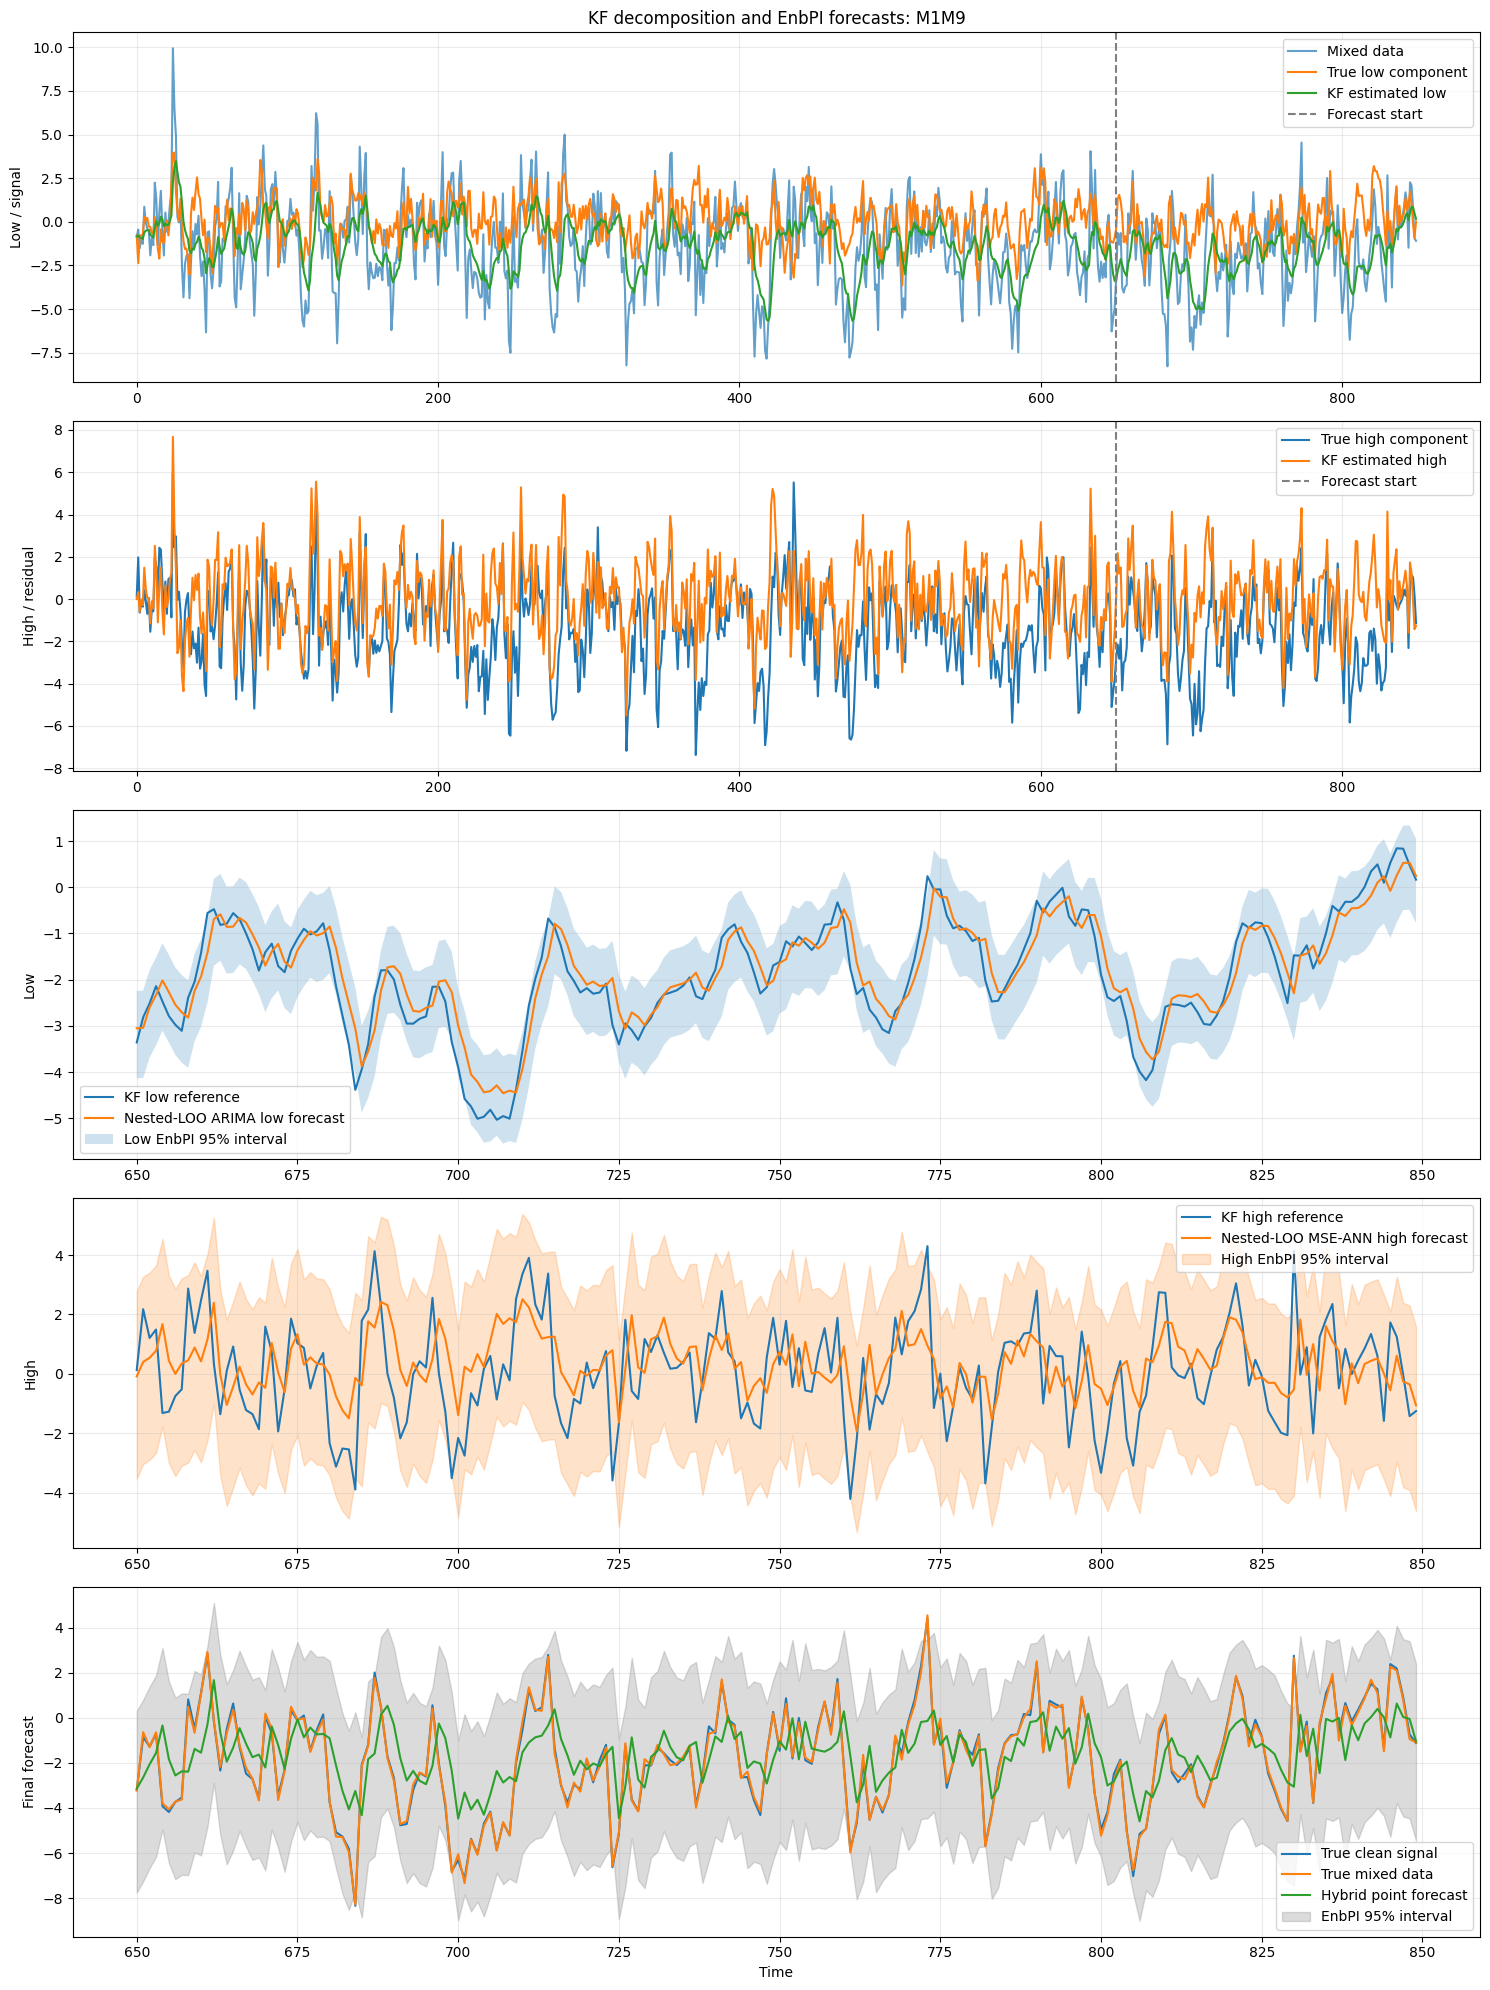

In [15]:
result = simulate_and_run(
    'm1m9', train_size=train_size, horizon=horizon, config=config, data_seed=2026
)
print(f'Actual result: train_size={result.train_size}, forecast_start={result.test_times[0]}, total_length={len(result.observed)}')
final_summary, component_summary = result.summary_tables()
print(f'Data seed={result.data_seed}, ensemble seed={result.config.random_state}')
display(final_summary)
display(component_summary)
display(result.frame().head())
plot_result(result);

## Diagnostics
Every training target must have at least one OOB model. The residual plots help assess the short-term i.i.d./mixing assumptions used by the EnbPI theory.

OOB model counts: 4 10.49763779527559 17


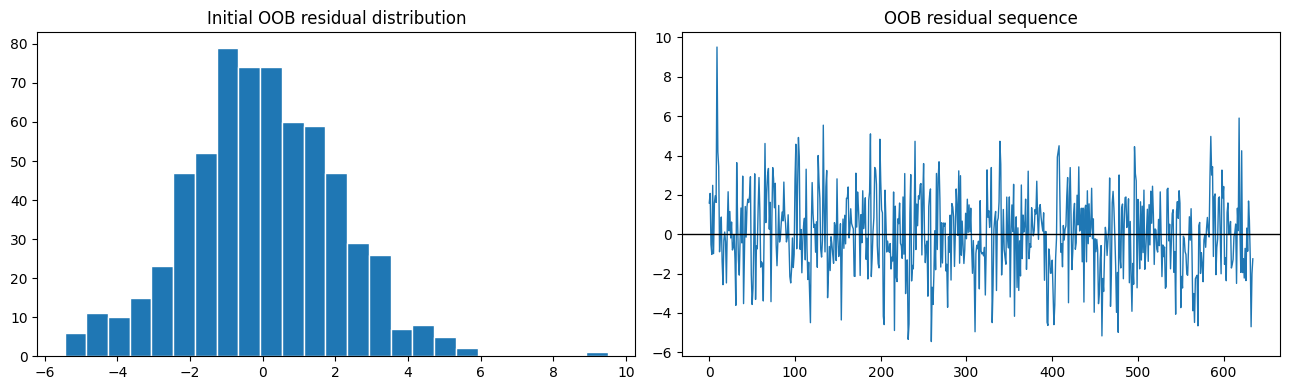

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(result.initial_oob_residuals, bins=25, edgecolor='white')
axes[0].set_title('Initial OOB residual distribution')
axes[1].plot(result.initial_oob_residuals, linewidth=1)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('OOB residual sequence')
fig.tight_layout();
print('OOB model counts:', result.oob_counts.min(), result.oob_counts.mean(), result.oob_counts.max())

## Monte Carlo summary

,metric,mean,std
0,mse,3.7933,0.5432
1,rmse,1.9429,0.1399
2,coverage,0.9453,0.0182
3,mean_width,7.5538,0.2875
4,low_kf_mse,0.2285,0.0490
5,low_kf_rmse,0.4753,0.0515
6,high_kf_mse,2.4211,0.3035
7,high_kf_rmse,1.5531,0.0977
8,low_true_mse,3.9817,1.1528
9,low_true_rmse,1.9764,0.2823


,run,data_seed,mse,rmse,coverage,coverage_percent,mean_width,median_width,low_kf_mse,low_kf_rmse,...,ann_selected_max_iter_mean,ann_rolling_validation_mse,ann_nonconverged_models,elapsed_seconds,low_true_mse,low_true_rmse,low_true_coverage,high_true_mse,high_true_rmse,high_true_coverage
0,1,479243620,3.6225,1.9033,0.930,93.0,7.0447,7.0593,0.2393,0.4892,...,125.0,3.2326,30.0,58.4400,3.1394,1.7718,0.410,4.9608,2.2273,0.825
1,2,454024514,3.6465,1.9096,0.950,95.0,7.4619,7.4567,0.2247,0.4740,...,125.0,2.8812,30.0,62.7188,3.4144,1.8478,0.365,3.8432,1.9604,0.875
2,3,1818751028,2.6224,1.6194,0.970,97.0,7.2892,7.2799,0.1349,0.3672,...,125.0,3.1959,30.0,59.4387,2.2957,1.5151,0.475,3.0338,1.7418,0.870
3,4,2288458700,4.1482,2.0367,0.930,93.0,7.8767,7.8138,0.2653,0.5150,...,125.0,2.6805,30.0,58.1257,5.2400,2.2891,0.365,7.6639,2.7684,0.770
4,5,2115331525,3.6966,1.9226,0.965,96.5,7.7353,7.7251,0.2305,0.4801,...,125.0,3.0692,30.0,60.1967,3.6043,1.8985,0.400,4.0551,2.0137,0.885
5,6,2666256175,4.1467,2.0364,0.900,90.0,7.2965,7.2966,0.2870,0.5357,...,125.0,2.7865,30.0,56.6580,3.6298,1.9052,0.360,5.8586,2.4205,0.790
6,7,975381835,3.7432,1.9347,0.915,91.5,7.3819,7.3914,0.1989,0.4460,...,125.0,3.3024,30.0,56.8771,4.0181,2.0045,0.355,5.1577,2.2711,0.805
7,8,2535166222,3.9408,1.9851,0.945,94.5,7.7145,7.7057,0.2274,0.4768,...,125.0,3.8670,30.0,59.5123,4.3559,2.0871,0.340,5.7270,2.3931,0.830
8,9,1079577930,4.4992,2.1211,0.930,93.0,7.9796,7.8799,0.2833,0.5323,...,125.0,4.1618,30.0,58.5731,6.3011,2.5102,0.285,9.2840,3.0470,0.710
9,10,3715024065,3.6913,1.9213,0.950,95.0,7.5355,7.5153,0.2295,0.4791,...,125.0,2.9641,30.0,58.8916,4.0934,2.0232,0.365,6.3062,2.5112,0.760


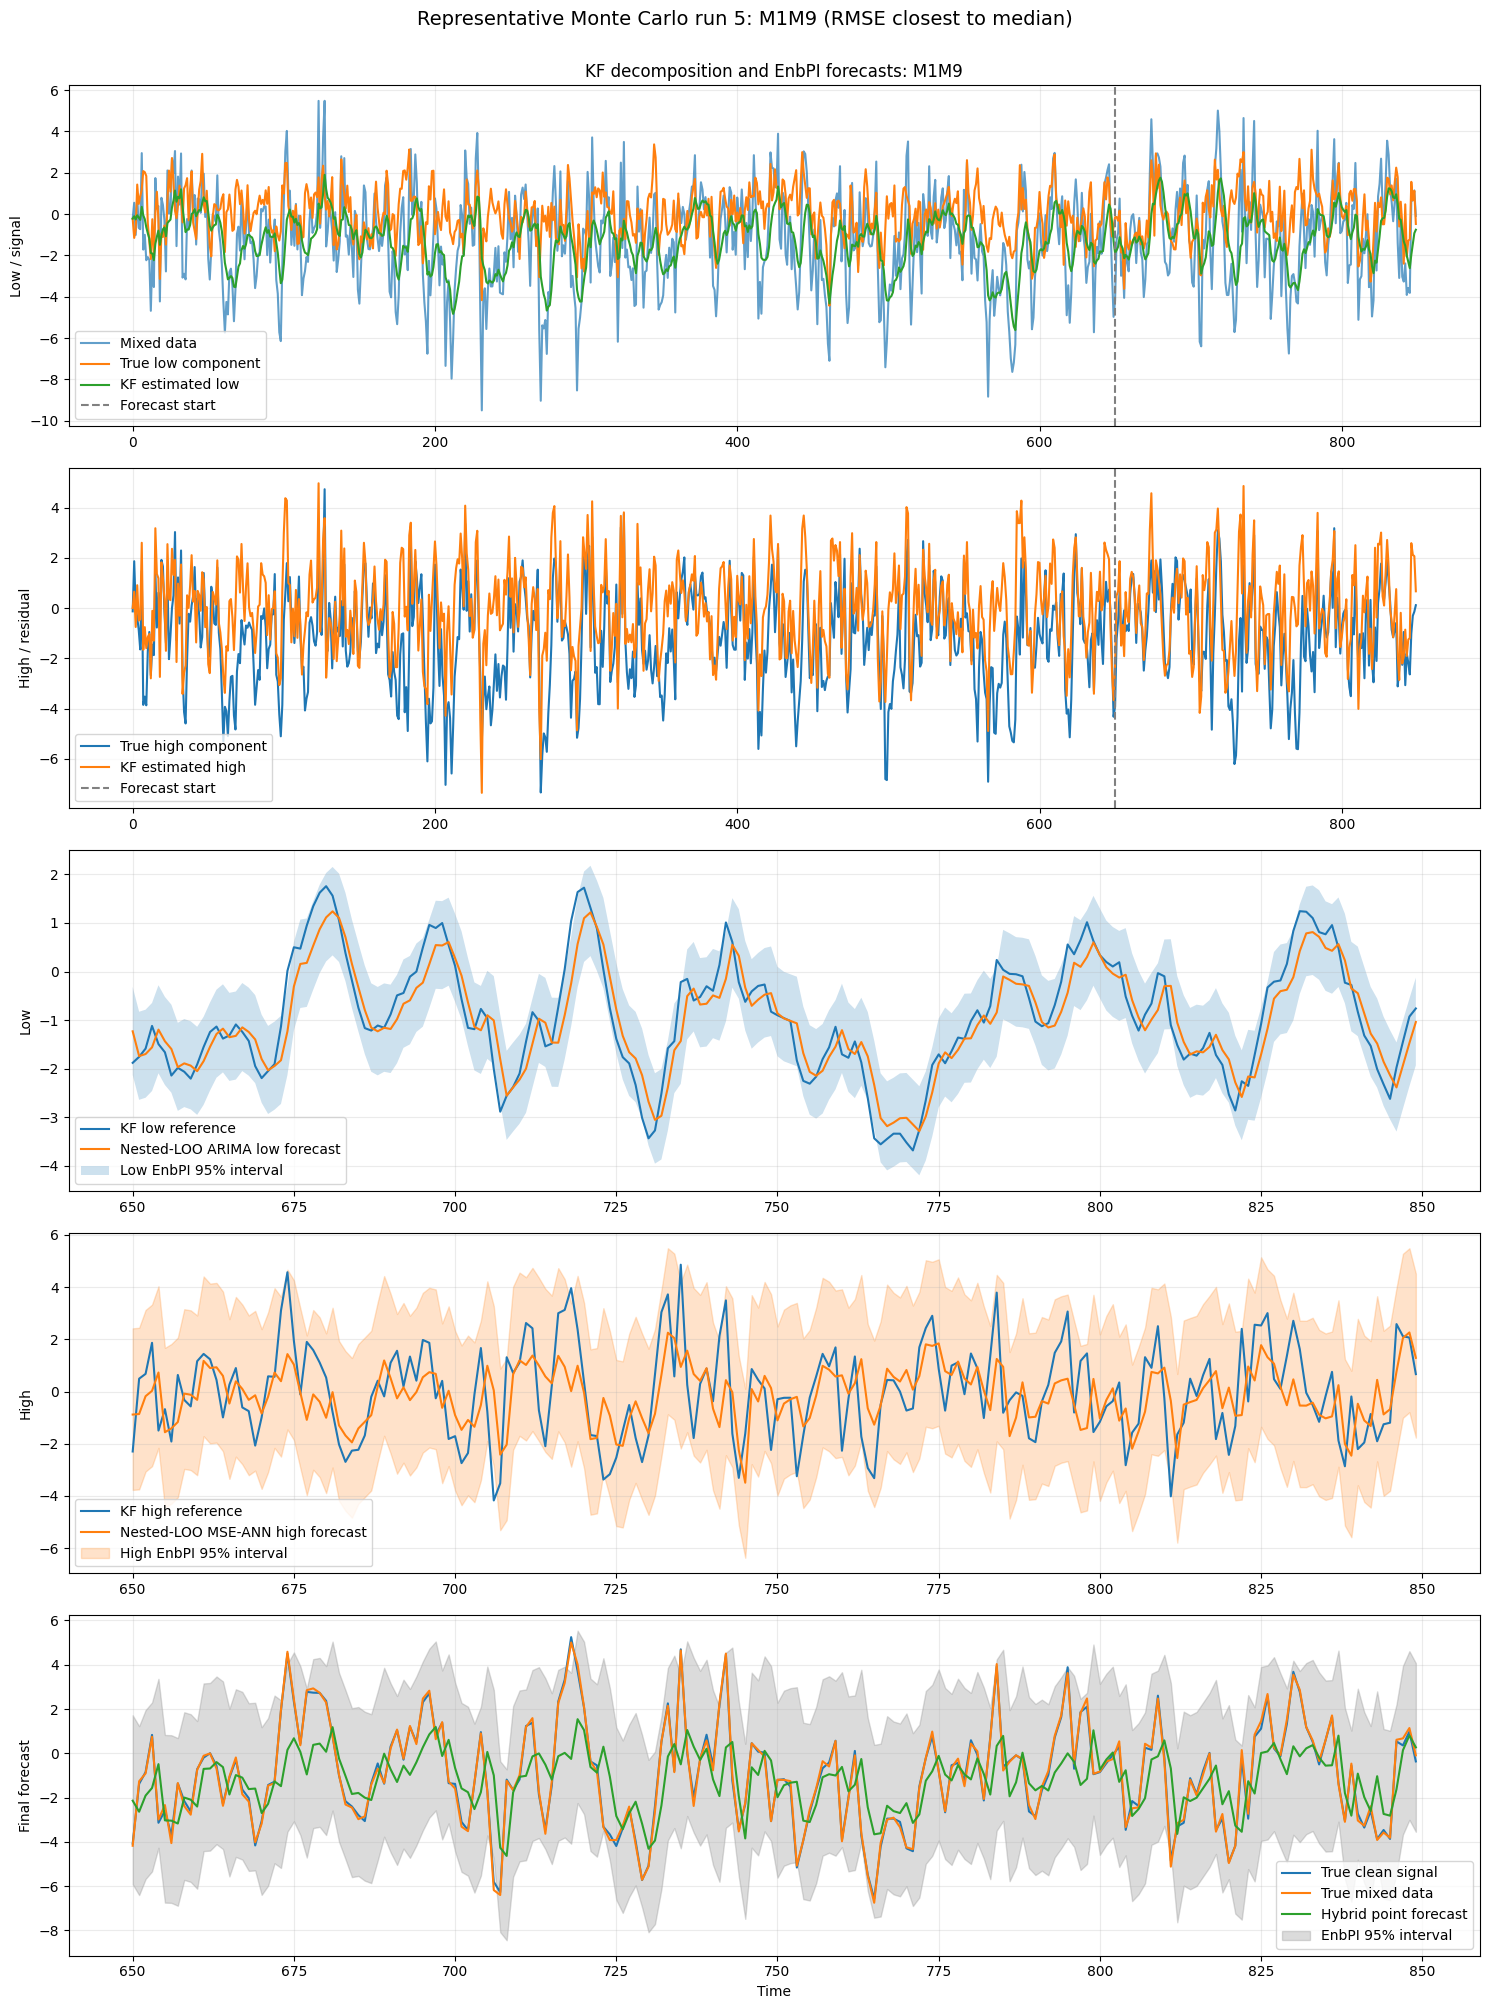

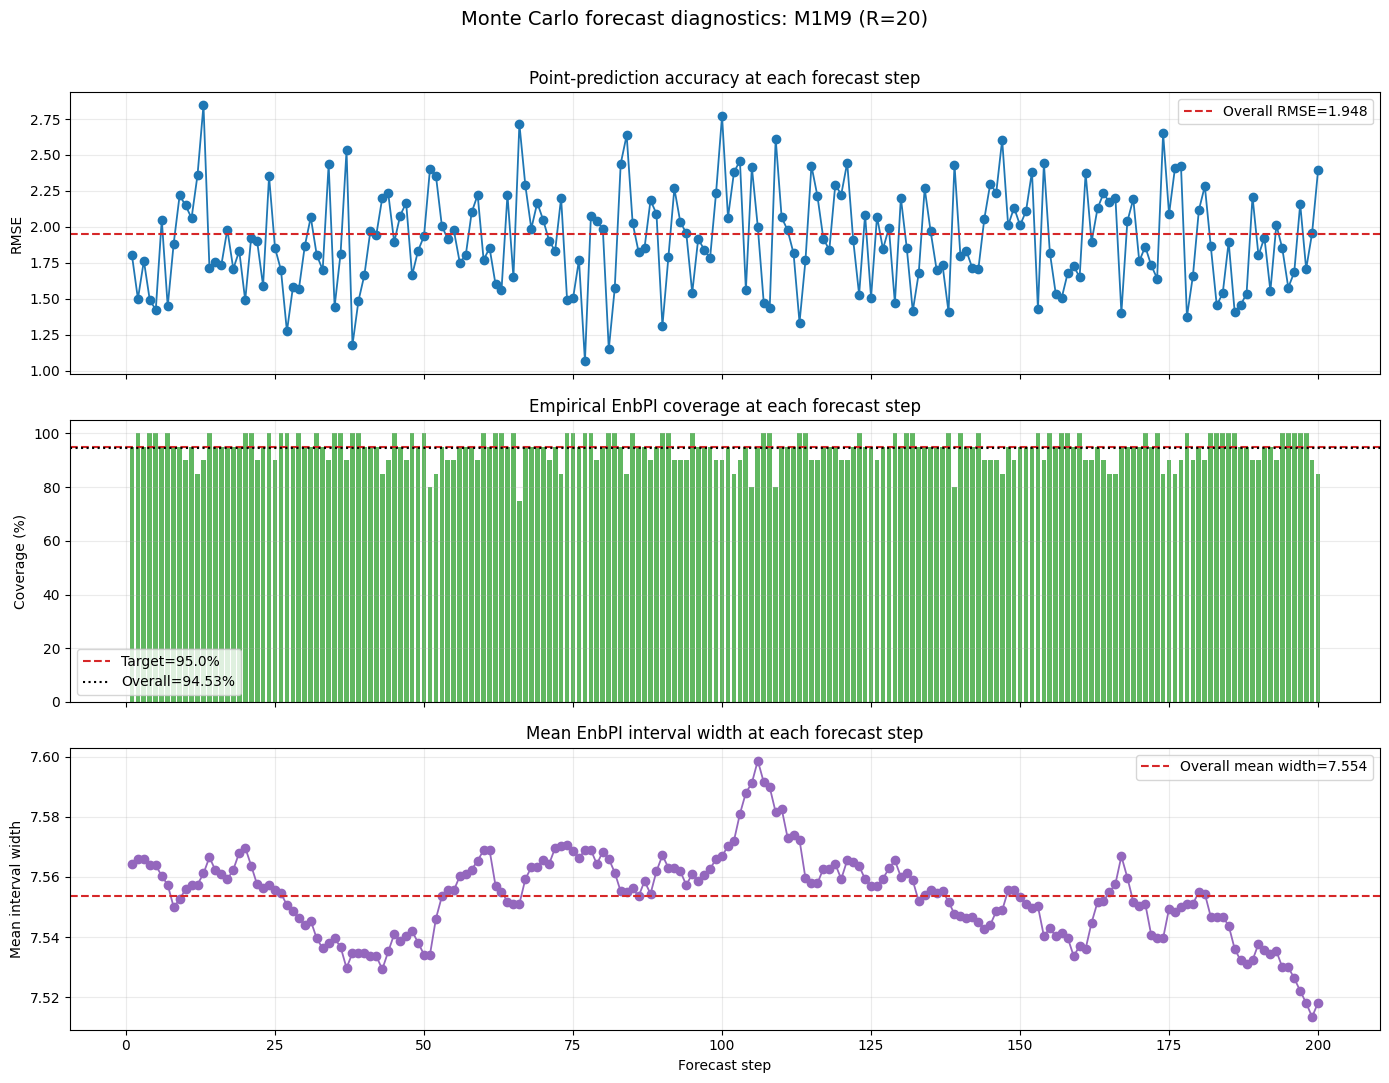

In [17]:
runs, summary, mc_results = monte_carlo_summary(
    'm1m9', n_runs=20, train_size=train_size, horizon=horizon, config=config, seed=2026
)
display(summary)
display(runs)
plot_monte_carlo_forecast_diagnostics(
    runs, mc_results, model_name='m1m9', alpha=config.alpha
);